   Country  Region  Year  HappinessScore  GDPPerCapita  SocialSupport  \
0  Finland  Europe  2018           4.420         0.750          1.060   
1  Finland  Europe  2019           4.753         0.741          0.889   
2  Finland  Europe  2020           4.523         0.769          1.405   
3  Finland  Europe  2021           4.553         0.757          1.535   
4  Finland  Europe  2022           4.691         0.771          0.969   

   LifeExpectancy  Freedom  Generosity  
0           0.474    0.697       0.158  
1           0.674    0.337       0.399  
2           0.712    0.310       0.373  
3           0.702    0.551       0.353  
4           0.558    0.581       0.466  

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         300 non-null    str    
 1   Region          300 non-null    str    
 2   Year            300 non-null    int6

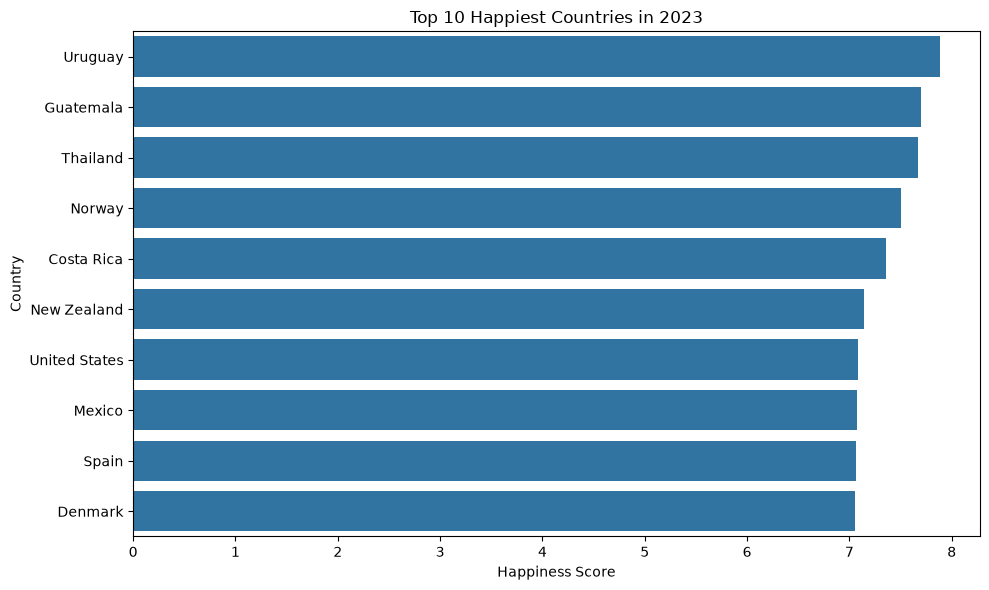

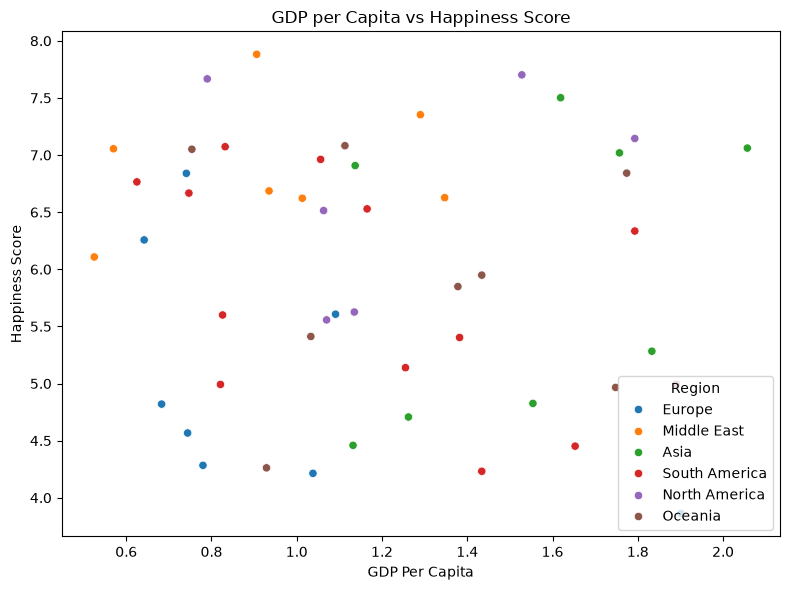

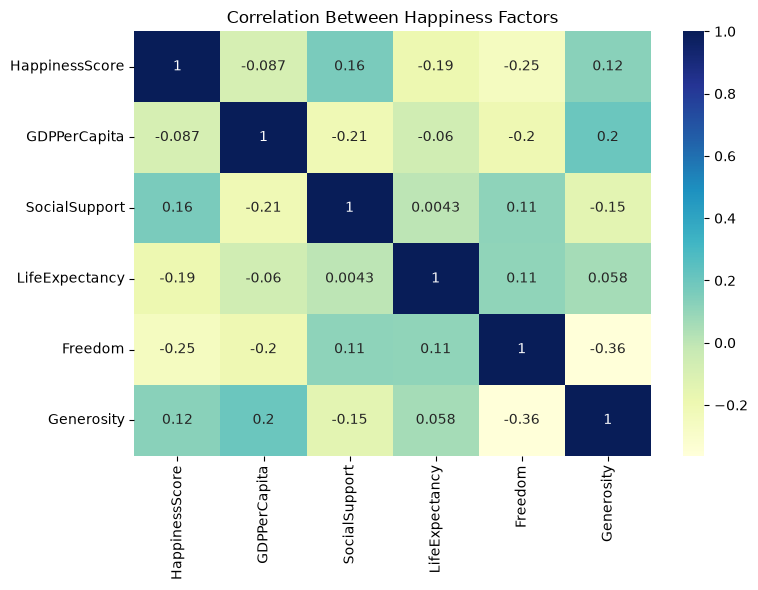

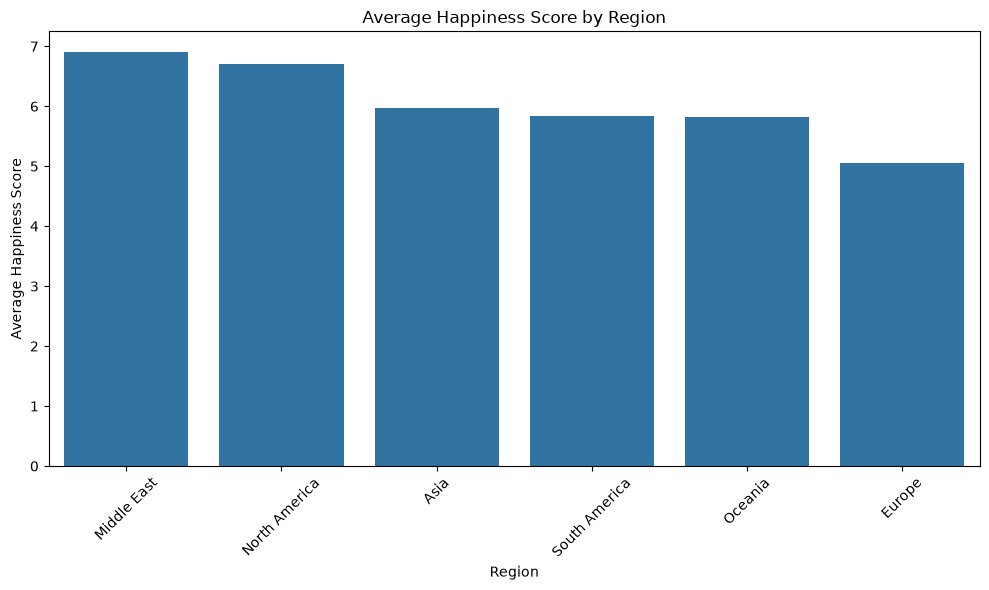

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("happiness_data.csv")

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())

latest_year = df["Year"].max()
latest_data = df[df["Year"] == latest_year]

top10 = latest_data.sort_values("HappinessScore", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="HappinessScore", y="Country", data=top10)
plt.title(f"Top 10 Happiest Countries in {latest_year}"  )
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="GDPPerCapita", y="HappinessScore", data=latest_data, hue="Region")
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP Per Capita")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
correlation = latest_data[["HappinessScore", "GDPPerCapita", "SocialSupport", "LifeExpectancy", "Freedom", "Generosity"]].corr()
sns.heatmap(correlation, annot=True, cmap="YlGnBu")
plt.title("Correlation Between Happiness Factors")
plt.tight_layout()
plt.show()

region_avg = latest_data.groupby("Region")["HappinessScore"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_avg.index, y=region_avg.values)
plt.xticks(rotation=45)
plt.title("Average Happiness Score by Region")
plt.xlabel("Region")
plt.ylabel("Average Happiness Score")
plt.tight_layout()
plt.show()